<a href="https://colab.research.google.com/github/heyavie/CSST101-3A-AY2627/blob/main/CSST101LABACT3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Table 1. Debate Arguments**

In [32]:
arguments <- data.frame(
  Argument_ID = c("A001", "A002", "A003", "A004", "A005", "A006", "A007", "A008"),
  Position = c("For", "For", "For", "Against", "Against", "Against", "Against", "Against"),
  Topic = c("Learning", "Productivity", "AI Literacy", "Academic Integrity", "Dependency", "Assessment", "Memory", "Writing"),
  Claim = c(
      "AI can provide students with immediate learning support.",
      "AI can help students complete routine academic tasks more efficiently.",
      "Allowing AI can use help students develope AI literacy.",
      "Undisclosed AI-generated work may create academic integrity concerns.",
      "Excessive AI use may reduce students' independent problem-solving practice.",
      "AI use may make it more difficult to determine whether submitted work reflects student learning.",
      "May cause struggling to recall and apply information in learning.",
      "With constant use of AI, students get less practice developing their ideas.")

)
arguments

Argument_ID,Position,Topic,Claim
<chr>,<chr>,<chr>,<chr>
A001,For,Learning,AI can provide students with immediate learning support.
A002,For,Productivity,AI can help students complete routine academic tasks more efficiently.
A003,For,AI Literacy,Allowing AI can use help students develope AI literacy.
A004,Against,Academic Integrity,Undisclosed AI-generated work may create academic integrity concerns.
A005,Against,Dependency,Excessive AI use may reduce students' independent problem-solving practice.
A006,Against,Assessment,AI use may make it more difficult to determine whether submitted work reflects student learning.
A007,Against,Memory,May cause struggling to recall and apply information in learning.
A008,Against,Writing,"With constant use of AI, students get less practice developing their ideas."


**Table 2. Evidence**

In [33]:
evidence <- data.frame(
  Evidence_ID = c("E001", "E002", "E003", "E004", "E005", "E006", "E007", "E008"),
  Argument_ID = c("A001", "A002", "A003", "A004", "A005", "A006", "A007", "A008"),
  Evidence_Type = c("Research", "Research", "Policy", "Policy", "Research", "Research", "Research", "Research"),
  Strength = c("Strong", "Moderate", "Strong", "Strong", "Moderate", "Strong", "Strong", "Strong")

)
evidence

Evidence_ID,Argument_ID,Evidence_Type,Strength
<chr>,<chr>,<chr>,<chr>
E001,A001,Research,Strong
E002,A002,Research,Moderate
E003,A003,Policy,Strong
E004,A004,Policy,Strong
E005,A005,Research,Moderate
E006,A006,Research,Strong
E007,A007,Research,Strong
E008,A008,Research,Strong


**Count Arguments**

In [34]:
table(arguments$Position)


Against     For 
      5       3 

In [35]:
nrow(arguments)

[1] 8

In [36]:
table(evidence$Strength)


Moderate   Strong 
       2        6 

In [37]:
nrow(evidence)

[1] 8

**Connect Table Arguments and Evidence**

In [19]:
knowledge_base <- merge(
  arguments,
  evidence,
  by = "Argument_ID"
)

knowledge_base

Argument_ID,Position,Topic,Claim,Evidence_ID,Evidence_Type,Strength
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
A001,For,Learning,AI can provide students with immediate learning support.,E001,Research,Strong
A002,For,Productivity,AI can help students complete routine academic tasks more efficiently.,E002,Research,Moderate
A003,For,AI Literacy,Allowing AI can use help students develope AI literacy.,E003,Policy,Strong
A004,Against,Academic Integrity,Undisclosed AI-generated work may create academic integrity concerns.,E004,Policy,Strong
A005,Against,Dependency,Excessive AI use may reduce students' independent problem-solving practice.,E005,Research,Moderate
A006,Against,Assessment,AI use may make it more difficult to determine whether submitted work reflects student learning.,E006,Research,Strong


**Convert Evidence Strength into a Score**

In [21]:
get_score <- function(strength){

  if(strength == "Strong"){
    return(3)
  } else if(strength == "Moderate"){
    return(2)
  } else if(strength == "Weak"){
    return(1)
  } else {
    return(0)
  }
}

**Add Evidence Score**

In [24]:
knowledge_base$Evidence_Score <- sapply(
  knowledge_base$Strength,
  get_score
)

knowledge_base

Argument_ID,Position,Topic,Claim,Evidence_ID,Evidence_Type,Strength,Evidence_Score
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
A001,For,Learning,AI can provide students with immediate learning support.,E001,Research,Strong,3
A002,For,Productivity,AI can help students complete routine academic tasks more efficiently.,E002,Research,Moderate,2
A003,For,AI Literacy,Allowing AI can use help students develope AI literacy.,E003,Policy,Strong,3
A004,Against,Academic Integrity,Undisclosed AI-generated work may create academic integrity concerns.,E004,Policy,Strong,3
A005,Against,Dependency,Excessive AI use may reduce students' independent problem-solving practice.,E005,Research,Moderate,2
A006,Against,Assessment,AI use may make it more difficult to determine whether submitted work reflects student learning.,E006,Research,Strong,3


**Convert Evidence Score to Support**

In [25]:
classify_support <- function(score){

  if(score == 3){
    return("Strongly Supported")
  } else if(score == 2){
    return("Moderately Supported")
  } else if(score ==1){
    return("Weakly Supported")
  } else {
    return("No Supported")
  }
}

classify_support(3)

[1] "Strongly Supported"

**Add Evidence Support**

In [29]:
knowledge_base$Support_level <- sapply(
  knowledge_base$Evidence_Score,
  classify_support
)

knowledge_base

Argument_ID,Position,Topic,Claim,Evidence_ID,Evidence_Type,Strength,Evidence_Score,Support_level
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>
A001,For,Learning,AI can provide students with immediate learning support.,E001,Research,Strong,3,Strongly Supported
A002,For,Productivity,AI can help students complete routine academic tasks more efficiently.,E002,Research,Moderate,2,Moderately Supported
A003,For,AI Literacy,Allowing AI can use help students develope AI literacy.,E003,Policy,Strong,3,Strongly Supported
A004,Against,Academic Integrity,Undisclosed AI-generated work may create academic integrity concerns.,E004,Policy,Strong,3,Strongly Supported
A005,Against,Dependency,Excessive AI use may reduce students' independent problem-solving practice.,E005,Research,Moderate,2,Moderately Supported
A006,Against,Assessment,AI use may make it more difficult to determine whether submitted work reflects student learning.,E006,Research,Strong,3,Strongly Supported


**Search by Topic**

In [40]:
library(dplyr)

search_by_topic <- function(df, search_term) {
  result <- df %>%
    filter(grepl(search_term, Topic, ignore.case = TRUE))

  if (nrow(result) == 0) {
    cat("No arguments found for topic containing:", search_term, "\n")
  } else {
    return(result)
  }
}

print(search_by_topic(knowledge_base, "AI"))


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




  Argument_ID Position       Topic
1        A003      For AI Literacy
                                                    Claim Evidence_ID
1 Allowing AI can use help students develope AI literacy.        E003
  Evidence_Type Strength Evidence_Score      Support_level
1        Policy   Strong              3 Strongly Supported


The `search_by_topic` function allows you to filter the `knowledge_base` by a specific topic. It's case-insensitive and will return all arguments related to the search term in the 'Topic' column.

**Evidence Strength Visualization**

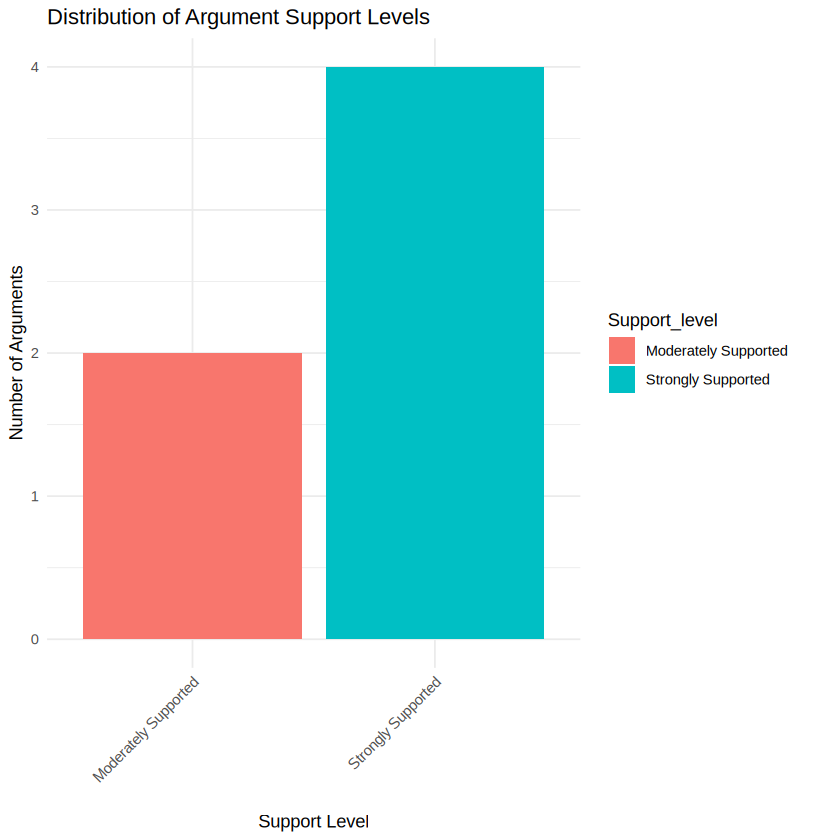

In [41]:
library(ggplot2)

strength_counts <- as.data.frame(table(knowledge_base$Support_level))
colnames(strength_counts) <- c("Support_level", "Count")

ggplot(strength_counts, aes(x = Support_level, y = Count, fill = Support_level)) +
  geom_bar(stat = "identity") +
  labs(title = "Distribution of Argument Support Levels",
       x = "Support Level",
       y = "Number of Arguments") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

**Formatted Final Debate Report**

In [42]:
report <- knowledge_base %>%
  group_by(Position, Topic) %>%
  summarise(
    Claims = paste(Claim, collapse = "; "),
    Support_Levels = paste(Support_level, collapse = "; ")
  ) %>%
  ungroup()

print(report)

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by Position and Topic.
ℹ Output is grouped by Position.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(Position, Topic))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


# A tibble: 6 × 4
  Position Topic              Claims                              Support_Levels
  <chr>    <chr>              <chr>                               <chr>         
1 Against  Academic Integrity Undisclosed AI-generated work may … Strongly Supp…
2 Against  Assessment         AI use may make it more difficult … Strongly Supp…
3 Against  Dependency         Excessive AI use may reduce studen… Moderately Su…
4 For      AI Literacy        Allowing AI can use help students … Strongly Supp…
5 For      Learning           AI can provide students with immed… Strongly Supp…
6 For      Productivity       AI can help students complete rout… Moderately Su…


This report summarizes the claims and their support levels grouped by their position (For/Against) and topic, providing an overview of the debate structure.